# 01b -- Optuna Hyperparameter Search | SWaT A1/A2 LSTM-VAE

### Contexto

El baseline v1 (hiperparametros manuales) obtuvo:

| Metrica | Baseline v1 |
|---------|-------------|
| ROC-AUC | 0.8170 |
| F1 | 0.757 |
| Recall | **0.615** (cuello de botella) |
| Precision | 0.984 |
| FPR | 0.001 |

La precision y FPR son casi perfectos. El problema es **recall bajo**:
el tau optimo es muy alto (4.354) y muchos ataques quedan por debajo.
Optuna debe encontrar una arquitectura con mejor discriminacion que
distribuya mejor los scores de ataque hacia valores mas altos.

### Espacio de busqueda

| Parametro | Rango | Tipo |
|---|---|---|
| `hidden_size` | {64, 128, 192, 256, 320} | categorical |
| `num_layers` | {1, 2} | categorical |
| `latent_dim` | {32, 64, 96, 128} | categorical |
| `disc_hidden` | {64, 128} | categorical |
| `beta` | [0.001, 0.3] | log-uniform |
| `alpha` | [0.75, 0.98] | uniform |
| `dropout` | [0.05, 0.40] | uniform |
| `lr` | [5e-5, 8e-4] | log-uniform |
| `batch_size` | {128, 256, 512} | categorical |
| `stride` | {5, 10, 15, 20} | categorical |

### Estrategia

- **Objetivo**: maximizar ROC-AUC (escala invariante al threshold).
- **Sampler**: TPESampler con 15 trials exploratorios al inicio.
- **Pruner**: MedianPruner -- corta trials que van mal a mitad.
- **Presupuesto**: 60 trials x 30 epocas maximo = ~2-4 horas GPU.
- **Reentrenamiento**: mejor trial con 100 epocas.
- **Datos**: se cargan UNA VEZ. Las ventanas se reconstruyen por trial
  solo cuando el stride cambia (cacheado).

### Flujo

```
01b (este): busqueda Optuna -> optuna_best_config.json
01c:        baseline definitivo que carga ese config
```


## 0. Imports

In [1]:
import json, joblib, random, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import warnings; warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas y parametros fijos

In [5]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

CLEAN_DIR   = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A1 & A2_Dec 2015'
NORMAL_XLSX = CLEAN_DIR / 'SWaT_Dataset_Normal_v1.xlsx'
ATTACK_XLSX = CLEAN_DIR / 'SWaT_Dataset_Attack_v0.xlsx'
SAVE_DIR    = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_swat_a1a2_optuna_v1'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Parametros fijos (no optimizados por Optuna)
WINDOW_SIZE   = 60      # Estandar en literatura SWaT
CLIP_VAL      = 5.0
WARMUP_SEC    = 1800    # 30 min (readme Normal_v0)
CONSEC_K      = 3       # Filtro consecutivo
N_TRIALS      = 60
MAX_TRIAL_EP  = 30      # Epocas rapidas por trial
TRIAL_PAT     = 8       # Early stop dentro del trial
MAX_RETRAIN   = 100     # Reentrenamiento del mejor trial
RETRAIN_PAT   = 15

# Definicion de sensores
CONTINUOUS_COLS = [
    'FIT101', 'LIT101', 'AIT201', 'AIT202', 'AIT203', 'FIT201',
    'DPIT301', 'FIT301', 'LIT301',
    'AIT401', 'AIT402', 'FIT401', 'LIT401',
    'AIT501', 'AIT502', 'AIT503', 'AIT504',
    'FIT501', 'FIT502', 'FIT503', 'FIT504',
    'PIT501', 'PIT502', 'PIT503', 'FIT601',
]
DISCRETE_COLS = [
    'MV101', 'P101', 'P102',
    'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206',
    'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302',
    'P401', 'P402', 'P403', 'P404', 'UV401',
    'P501', 'P502',
    'P601', 'P602', 'P603',
]
ALL_SENSOR_COLS = CONTINUOUS_COLS + DISCRETE_COLS

print(f'Normal : {NORMAL_XLSX.exists()}')
print(f'Attack : {ATTACK_XLSX.exists()}')
print(f'Save   : {SAVE_DIR}')
print(f'Sensores: {len(CONTINUOUS_COLS)} cont + {len(DISCRETE_COLS)} disc = {len(ALL_SENSOR_COLS)}')
print(f'N_TRIALS={N_TRIALS} | trial_ep={MAX_TRIAL_EP} | retrain_ep={MAX_RETRAIN}')


Normal : True
Attack : True
Save   : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_optuna_v1
Sensores: 25 cont + 26 disc = 51
N_TRIALS=60 | trial_ep=30 | retrain_ep=100


## 2. Carga de datos (una sola vez, fuera del loop de trials)

In [6]:
def load_swat_xlsx(path, label_is_string=True):
    df = pd.read_excel(path, header=1)
    df.columns = [c.strip() for c in df.columns]
    df['Timestamp'] = pd.to_datetime(
        df['Timestamp'].astype(str).str.strip(),
        format='%d/%m/%Y %I:%M:%S %p'
    )
    df = df.sort_values('Timestamp').reset_index(drop=True)
    for col in ALL_SENSOR_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if label_is_string and 'Normal/Attack' in df.columns:
        df['Normal/Attack'] = df['Normal/Attack'].astype(str).str.strip().replace('A ttack','Attack')
        df['attack_label']  = (df['Normal/Attack'] == 'Attack').astype(int)
    else:
        df['attack_label'] = 0
    return df

print('Cargando Normal_v1...')
df_normal = load_swat_xlsx(NORMAL_XLSX, label_is_string=False)
t0_n = df_normal['Timestamp'].min()
df_normal = df_normal[
    df_normal['Timestamp'] >= t0_n + pd.Timedelta(seconds=WARMUP_SEC)
].reset_index(drop=True)

n = len(df_normal)
df_train = df_normal.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_normal.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,}')

# Scaler fiteado en train
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[CONTINUOUS_COLS].values)
disc_max = df_train[DISCRETE_COLS].max().replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[CONTINUOUS_COLS] = np.clip(
        scaler_cont.transform(df[CONTINUOUS_COLS].values), -CLIP_VAL, CLIP_VAL
    )
    df[DISCRETE_COLS] = (df[DISCRETE_COLS] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)

# Attack_v0 para evaluacion
print('Cargando Attack_v0...')
df_attack = load_swat_xlsx(ATTACK_XLSX, label_is_string=True)
df_eval_sc = df_attack.copy()
df_eval_sc[CONTINUOUS_COLS] = np.clip(
    scaler_cont.transform(df_eval_sc[CONTINUOUS_COLS].values), -CLIP_VAL, CLIP_VAL
)
df_eval_sc[DISCRETE_COLS] = (df_eval_sc[DISCRETE_COLS] / disc_max).clip(0, 1)
labs_eval = df_attack['attack_label'].values

joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')
print(f'Datos cargados. Attack: Normal={( labs_eval==0).sum():,} | Attack={(labs_eval==1).sum():,}')


Cargando Normal_v1...
Train: 295,920 | Val: 98,640
Cargando Attack_v0...
Datos cargados. Attack: Normal=395,298 | Attack=54,621


## 3. Funciones de ventanas y evaluacion

In [7]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins \
           else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

# Cache de ventanas por stride para no recalcular innecesariamente
_window_cache = {}

def get_windows(stride):
    """Retorna (tr_c, tr_d, va_c, va_d, eval_c, eval_d, y_eval)
    Cachea por stride para que trials con el mismo stride reusen los arrays.
    """
    if stride not in _window_cache:
        tr_c = create_windows(df_train_sc[CONTINUOUS_COLS].values.astype(np.float32), WINDOW_SIZE, stride)
        tr_d_raw = create_windows(df_train_sc[DISCRETE_COLS].values.astype(np.float32), WINDOW_SIZE, stride)
        tr_d = summarize_discrete_windows(tr_d_raw, DISCRETE_COLS).values.astype(np.float32)

        va_c = create_windows(df_val_sc[CONTINUOUS_COLS].values.astype(np.float32), WINDOW_SIZE, stride)
        va_d_raw = create_windows(df_val_sc[DISCRETE_COLS].values.astype(np.float32), WINDOW_SIZE, stride)
        va_d = summarize_discrete_windows(va_d_raw, DISCRETE_COLS).values.astype(np.float32)

        ev_c = create_windows(df_eval_sc[CONTINUOUS_COLS].values.astype(np.float32), WINDOW_SIZE, stride)
        ev_d_raw = create_windows(df_eval_sc[DISCRETE_COLS].values.astype(np.float32), WINDOW_SIZE, stride)
        ev_d = summarize_discrete_windows(ev_d_raw, DISCRETE_COLS).values.astype(np.float32)

        y_ev = np.array(
            [int(np.any(labs_eval[s:s+WINDOW_SIZE]==1))
             for s in range(0, len(labs_eval)-WINDOW_SIZE+1, stride)],
            dtype=int
        )
        _window_cache[stride] = (tr_c, tr_d, va_c, va_d, ev_c, ev_d, y_ev)
        print(f'  [cache] stride={stride}: tr={tr_c.shape[0]:,} | va={va_c.shape[0]:,} | ev={ev_c.shape[0]:,}')
    return _window_cache[stride]


def consec_filter(scores_arr, tau, k):
    raw = (scores_arr > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for ii in range(k-1, len(raw)):
        out[ii] = int(raw[ii-k+1:ii+1].all())
    return out


def compute_scores(model, Xc, Xd, alpha, bs=512):
    ldr = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                   torch.tensor(Xd, dtype=torch.float32)),
                     batch_size=bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in ldr:
            xc, xd = xc.to(device), xd.to(device)
            xc_h, xd_h, mu, _ = model(xc, xd)
            ec_l.extend(torch.mean((xc_h-xc)**2, dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_h-xd)**2, dim=1).cpu().numpy())
    ec = np.array(ec_l); ed = np.array(ed_l)
    return alpha*ec + (1-alpha)*ed


print(f'Funciones definidas. Disc summary dim: {len(DISCRETE_COLS)*4}')
print('Precalculando ventanas para stride=10 (baseline)...')
_ = get_windows(10)


Funciones definidas. Disc summary dim: 104
Precalculando ventanas para stride=10 (baseline)...
  [cache] stride=10: tr=29,587 | va=9,859 | ev=44,986


## 4. Arquitectura LSTM-VAE

In [8]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, seq_len, disc_dim, hidden_size=128, num_layers=2,
                 latent_dim=64, disc_hidden=64, dropout=0.2):
        super().__init__()
        cont_size = len(CONTINUOUS_COLS)
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha*(mse_c + beta*kl) + (1-alpha)*mse_d, mse_c, mse_d, kl

print('Arquitectura definida.')


Arquitectura definida.


## 5. Funcion objetivo Optuna

Cada trial:
1. Sugiere hiperparametros del espacio de busqueda.
2. Obtiene ventanas (del cache si el stride ya fue calculado).
3. Entrena maximo `MAX_TRIAL_EP` epocas.
4. Reporta AUC cada 5 epocas (permite pruning).
5. Devuelve ROC-AUC sobre Attack_v0 completo.
6. Libera GPU antes de salir.

In [9]:
def train_eval_trial(params, max_epochs, patience, trial=None):
    """Entrena y evalua un modelo con los params dados.
    Si trial != None: reporta AUC intermedios para pruning.
    Retorna (auc, best_state_dict).
    """
    stride   = params['stride']
    alpha    = params['alpha']
    beta     = params['beta']
    bs       = params['batch_size']

    tr_c, tr_d, va_c, va_d, ev_c, ev_d, y_ev = get_windows(stride)
    disc_dim = tr_d.shape[1]

    model = HybridLSTMVAE(
        seq_len     = WINDOW_SIZE,
        disc_dim    = disc_dim,
        hidden_size = params['hidden_size'],
        num_layers  = params['num_layers'],
        latent_dim  = params['latent_dim'],
        disc_hidden = params['disc_hidden'],
        dropout     = params['dropout'],
    ).to(device)

    tr_ldr = DataLoader(
        TensorDataset(torch.tensor(tr_c, dtype=torch.float32),
                      torch.tensor(tr_d, dtype=torch.float32)),
        batch_size=bs, shuffle=True, drop_last=True)
    va_ldr = DataLoader(
        TensorDataset(torch.tensor(va_c, dtype=torch.float32),
                      torch.tensor(va_d, dtype=torch.float32)),
        batch_size=bs, shuffle=False)

    opt   = torch.optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=6, min_lr=1e-7)

    best_val = float('inf'); best_wts = None; no_imp = 0

    for ep in range(1, max_epochs + 1):
        model.train()
        for xc, xd in tr_ldr:
            xc, xd = xc.to(device), xd.to(device)
            opt.zero_grad()
            xc_h, xd_h, mu, lv = model(xc, xd)
            loss = elbo_loss(xc, xc_h, xd, xd_h, mu, lv, alpha, beta)[0]
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xc, xd in va_ldr:
                xc, xd = xc.to(device), xd.to(device)
                xc_h, xd_h, mu, lv = model(xc, xd)
                vl += elbo_loss(xc, xc_h, xd, xd_h, mu, lv, alpha, beta)[0].item()
        vl /= len(va_ldr)
        sched.step(vl)

        if vl < best_val - 1e-6:
            best_val = vl; no_imp = 0
            best_wts = {kk: vv.clone() for kk, vv in model.state_dict().items()}
        else:
            no_imp += 1

        # Pruning: reportar AUC cada 5 epocas
        if trial is not None and ep % 5 == 0 and best_wts is not None:
            model.load_state_dict(best_wts)
            sc_inter = compute_scores(model, ev_c, ev_d, alpha)
            auc_inter = roc_auc_score(y_ev, sc_inter)
            trial.report(auc_inter, ep)
            if trial.should_prune():
                del model; torch.cuda.empty_cache(); gc.collect()
                raise optuna.exceptions.TrialPruned()
            model.train()

        if no_imp >= patience: break

    model.load_state_dict(best_wts)
    model.eval()
    sc = compute_scores(model, ev_c, ev_d, alpha)
    auc = roc_auc_score(y_ev, sc)

    state = {kk: vv.cpu().clone() for kk, vv in model.state_dict().items()}
    del model; torch.cuda.empty_cache(); gc.collect()
    return auc, state


def objective(trial):
    params = {
        'hidden_size' : trial.suggest_categorical('hidden_size', [64, 128, 192, 256, 320]),
        'num_layers'  : trial.suggest_categorical('num_layers',  [1, 2]),
        'latent_dim'  : trial.suggest_categorical('latent_dim',  [32, 64, 96, 128]),
        'disc_hidden' : trial.suggest_categorical('disc_hidden', [64, 128]),
        'beta'        : trial.suggest_float('beta',    0.001, 0.30, log=True),
        'alpha'       : trial.suggest_float('alpha',   0.75,  0.98),
        'dropout'     : trial.suggest_float('dropout', 0.05,  0.40),
        'lr'          : trial.suggest_float('lr',      5e-5,  8e-4, log=True),
        'batch_size'  : trial.suggest_categorical('batch_size', [128, 256, 512]),
        'stride'      : trial.suggest_categorical('stride',     [5, 10, 15, 20]),
    }
    auc, _ = train_eval_trial(params, MAX_TRIAL_EP, TRIAL_PAT, trial=trial)
    return auc


print('Funcion objetivo definida.')


Funcion objetivo definida.


## 6. Ejecutar estudio Optuna

El estudio se persiste en SQLite -- si se interrumpe, la celda reanuda
desde donde quedo al volver a ejecutarse.

In [10]:
DB_PATH = SAVE_DIR / 'optuna_study.db'

study = optuna.create_study(
    study_name     = 'lstm_vae_swat_a1a2_v1',
    direction      = 'maximize',
    sampler        = TPESampler(seed=SEED, n_startup_trials=15),
    pruner         = MedianPruner(n_startup_trials=15, n_warmup_steps=10, interval_steps=5),
    storage        = f'sqlite:///{DB_PATH}',
    load_if_exists = True,
)

done  = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
left  = max(0, N_TRIALS - done)
print(f'Trials completos: {done} | Pendientes: {left}')

if left > 0:
    study.optimize(
        objective,
        n_trials          = left,
        show_progress_bar = True,
    )

best = study.best_trial
print(f'\nMejor trial #{best.number} -- ROC-AUC: {best.value:.4f}')
for k, v in best.params.items():
    print(f'  {k:<15}: {v}')


Trials completos: 0 | Pendientes: 60


  0%|          | 0/60 [00:00<?, ?it/s]

  [cache] stride=5: tr=59,173 | va=19,717 | ev=89,972


Best trial: 2. Best value: 0.826691:   5%|▌         | 3/60 [15:24<3:41:55, 233.61s/it] 

  [cache] stride=15: tr=19,725 | va=6,573 | ev=29,991


Best trial: 6. Best value: 0.827592:  12%|█▏        | 7/60 [24:19<2:12:03, 149.50s/it]

  [cache] stride=20: tr=14,794 | va=4,930 | ev=22,493


Best trial: 13. Best value: 0.831396: 100%|██████████| 60/60 [59:00<00:00, 59.01s/it]  


Mejor trial #13 -- ROC-AUC: 0.8314
  hidden_size    : 128
  num_layers     : 1
  latent_dim     : 96
  disc_hidden    : 128
  beta           : 0.06727599600965771
  alpha          : 0.8775014320776222
  dropout        : 0.2641022611820233
  lr             : 0.00016003641872536727
  batch_size     : 512
  stride         : 10


## 7. Analisis del estudio

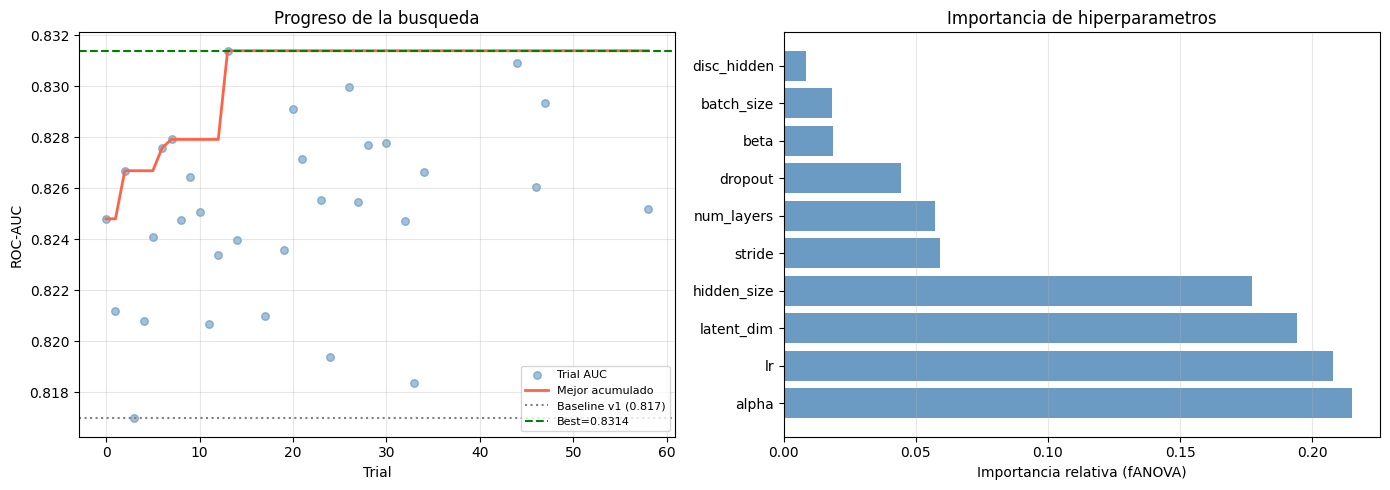

In [11]:
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_aucs = [t.value for t in completed]
best_so_far = np.maximum.accumulate(trial_aucs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter([t.number for t in completed], trial_aucs,
                alpha=0.5, s=30, color='steelblue', label='Trial AUC')
axes[0].plot([t.number for t in completed], best_so_far,
             color='tomato', lw=2, label='Mejor acumulado')
axes[0].axhline(0.817, color='gray', linestyle=':', lw=1.5, label='Baseline v1 (0.817)')
axes[0].axhline(best.value, color='green', linestyle='--', lw=1.5,
                label=f'Best={best.value:.4f}')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Progreso de la busqueda')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

try:
    importances = optuna.importance.get_param_importances(study)
    names  = list(importances.keys())
    values = list(importances.values())
    axes[1].barh(names, values, color='steelblue', alpha=0.8)
    axes[1].set_xlabel('Importancia relativa (fANOVA)')
    axes[1].set_title('Importancia de hiperparametros')
    axes[1].grid(True, alpha=0.3, axis='x')
except Exception as e:
    axes[1].text(0.5, 0.5, f'No disponible:\n{e}', ha='center', va='center',
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'optuna_progress.png'), dpi=120, bbox_inches='tight')
plt.show()


In [12]:
# Top 10 trials
top10 = sorted(completed, key=lambda t: t.value, reverse=True)[:10]
print('Top 10 trials:')
header = f'{"#":>4}  {"AUC":>7}  {"hidden":>7}  {"layers":>7}  {"latent":>7}  '\
         f'{"disc_h":>7}  {"beta":>7}  {"alpha":>7}  {"drop":>6}  {"lr":>9}  {"bs":>5}  {"stride":>7}'
print(header)
print('-' * len(header))
for t in top10:
    p = t.params
    print(f'{t.number:>4}  {t.value:>7.4f}  {p["hidden_size"]:>7}  {p["num_layers"]:>7}  '
          f'{p["latent_dim"]:>7}  {p["disc_hidden"]:>7}  {p["beta"]:>7.4f}  '
          f'{p["alpha"]:>7.4f}  {p["dropout"]:>6.3f}  {p["lr"]:>9.2e}  '
          f'{p["batch_size"]:>5}  {p["stride"]:>7}')


Top 10 trials:
   #      AUC   hidden   layers   latent   disc_h     beta    alpha    drop         lr     bs   stride
------------------------------------------------------------------------------------------------------
  13   0.8314      128        1       96      128   0.0673   0.8775   0.264   1.60e-04    512       10
  44   0.8309       64        1       96      128   0.0050   0.8044   0.148   1.22e-04    128        5
  26   0.8300      128        1       96      128   0.1196   0.7534   0.246   6.82e-05    256       20
  47   0.8294       64        2       32      128   0.0022   0.7668   0.348   8.13e-05    128       10
  20   0.8291      320        2       96      128   0.0891   0.7548   0.364   1.55e-04    128       20
   7   0.8279      192        2      128      128   0.0019   0.9627   0.357   1.02e-04    256       20
  30   0.8278      128        1       96      128   0.0637   0.8073   0.143   1.62e-04    128        5
  28   0.8277      128        1       96      128   0.1594

## 8. Reentrenamiento del mejor trial

Entrena con 100 epocas y patience=15 para obtener el modelo definitivo.

In [13]:
best_params = dict(best.params)
print('Reentrenando con:')
for k, v in best_params.items(): print(f'  {k:<15}: {v}')

best_auc_retrain, best_state = train_eval_trial(
    best_params,
    max_epochs = MAX_RETRAIN,
    patience   = RETRAIN_PAT,
    trial      = None,   # Sin pruning
)
print(f'\nROC-AUC reentrenamiento: {best_auc_retrain:.4f}')
print(f'ROC-AUC trial original : {best.value:.4f}')


Reentrenando con:
  hidden_size    : 128
  num_layers     : 1
  latent_dim     : 96
  disc_hidden    : 128
  beta           : 0.06727599600965771
  alpha          : 0.8775014320776222
  dropout        : 0.2641022611820233
  lr             : 0.00016003641872536727
  batch_size     : 512
  stride         : 10

ROC-AUC reentrenamiento: 0.8216
ROC-AUC trial original : 0.8314


## 9. Guardar config y modelo del mejor trial

In [14]:
torch.save(best_state, SAVE_DIR / 'best_model_state.pt')

stride_best = best_params['stride']
_, _, _, _, ev_c_b, ev_d_b, y_ev_b = get_windows(stride_best)

optuna_cfg = {
    'study_name'        : 'lstm_vae_swat_a1a2_v1',
    'best_trial'        : best.number,
    'best_auc_trial'    : float(best.value),
    'best_auc_retrain'  : float(best_auc_retrain),
    'n_trials_run'      : len(completed),
    'dataset_train'     : 'SWaT_Dataset_Normal_v1.xlsx',
    'dataset_eval'      : 'SWaT_Dataset_Attack_v0.xlsx',
    'window_size'       : WINDOW_SIZE,
    'clip_val'          : CLIP_VAL,
    'warmup_sec'        : WARMUP_SEC,
    'consec_k'          : CONSEC_K,
    'continuous_cols'   : CONTINUOUS_COLS,
    'discrete_cols'     : DISCRETE_COLS,
    'disc_summary_dim'  : int(len(DISCRETE_COLS) * 4),
    'best_params'       : {k: (float(v) if isinstance(v, float) else v)
                           for k, v in best_params.items()},
}

with open(SAVE_DIR / 'optuna_best_config.json', 'w') as f:
    json.dump(optuna_cfg, f, indent=4)

print('Guardado en:', SAVE_DIR.resolve())
for fp_ in sorted(SAVE_DIR.iterdir()):
    print(f'  {fp_.name}')
print()
print(f'Mejor trial AUC    : {best.value:.4f}')
print(f'Reentrenamiento AUC: {best_auc_retrain:.4f}')
print(f'-> Cargar en 01c desde: {SAVE_DIR / "optuna_best_config.json"}')


Guardado en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_optuna_v1
  best_model_state.pt
  disc_max_dict.pkl
  optuna_best_config.json
  optuna_progress.png
  optuna_study.db
  scaler_cont.pkl

Mejor trial AUC    : 0.8314
Reentrenamiento AUC: 0.8216
-> Cargar en 01c desde: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_swat_a1a2_optuna_v1\optuna_best_config.json
